In [1]:
!pip install -q tensorflow

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [7]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"reyaoberoi2005","key":"d42bbf6329cf47139e7068031952df91"}'}

In [8]:
import os

!mkdir -p /root/.kaggle
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [9]:
!kaggle datasets download -d ambarish/breakhis

Dataset URL: https://www.kaggle.com/datasets/ambarish/breakhis
License(s): unknown
100% 3.99G/3.99G [03:44<00:00, 19.0MB/s]



In [10]:
!unzip breakhis.zip -d breakhis

Streaming output truncated to the last 5000 lines.
  inflating: breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-12312/40X/SOB_M_DC-14-12312-40-026.png  
  inflating: breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-12312/40X/SOB_M_DC-14-12312-40-027.png  
  inflating: breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-12312/40X/SOB_M_DC-14-12312-40-028.png  
  inflating: breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-12312/40X/SOB_M_DC-14-12312-40-029.png  
  inflating: breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-12312/40X/SOB_M_DC-14-12312-40-030.png  
  inflating: breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-12312/40X/SOB_M_DC-14-12312-40-031.png  
  inflating: breakhis/Bre

In [14]:
import os
import shutil

input_dir = "/content/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast"
output_dir = "/content/flat_data"

classes = ["benign", "malignant"]

for cls in classes:
    os.makedirs(os.path.join(output_dir, cls), exist_ok=True)
    class_path = os.path.join(input_dir, cls)

    for sob_type_folder in os.listdir(class_path):
        sob_type_path = os.path.join(class_path, sob_type_folder)
        if os.path.isdir(sob_type_path):
            for tumor_type_folder in os.listdir(sob_type_path):
                tumor_type_path = os.path.join(sob_type_path, tumor_type_folder)
                if os.path.isdir(tumor_type_path):
                    for patient_id_folder in os.listdir(tumor_type_path):
                        patient_id_path = os.path.join(tumor_type_path, patient_id_folder)
                        if os.path.isdir(patient_id_path):
                            for magnification_folder in os.listdir(patient_id_path):
                                magnification_path = os.path.join(patient_id_path, magnification_folder)
                                if os.path.isdir(magnification_path):
                                    for image_file in os.listdir(magnification_path):
                                        src = os.path.join(magnification_path, image_file)

                                        if os.path.isfile(src):
                                            # Rename to avoid duplicates and include full path info
                                            new_name = f"{cls}_{sob_type_folder}_{tumor_type_folder}_{patient_id_folder}_{magnification_folder}_{image_file}"
                                            dst = os.path.join(output_dir, cls, new_name)
                                            shutil.copy(src, dst)

print("Dataset Flattened!")

Dataset Flattened!


In [38]:
import random

base_dir = "/content/flat_data"
output_dir = "/content/data"

splits = ['train', 'val', 'test']
classes = ['benign', 'malignant']

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

def split_data(source):
    files = os.listdir(source)
    random.shuffle(files)

    total = len(files)
    train_end = int(0.7 * total)
    val_end = int(0.85 * total)

    for i, file in enumerate(files):
        src = os.path.join(source, file)

        if i < train_end:
            dst = os.path.join(output_dir, 'train')
        elif i < val_end:
            dst = os.path.join(output_dir, 'val')
        else:
            dst = os.path.join(output_dir, 'test')

        shutil.copy(src, os.path.join(dst, os.path.basename(source), file))

for cls in classes:
    split_data(os.path.join(base_dir, cls))

print("Data Split Done!")

Data Split Done!


In [39]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8,1.2]
)

val_datagen = ImageDataGenerator()

val_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    "/content/data/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    "/content/data/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = val_datagen.flow_from_directory(
    "/content/data/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 7173 images belonging to 2 classes.
Found 2185 images belonging to 2 classes.
Found 2182 images belonging to 2 classes.


In [42]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.594), 1: np.float64(0.7285191956124314)}


In [43]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetV2B0

base_model = EfficientNetV2B0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(224,224,3)),
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

In [45]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2
)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 288s 1s/step - accuracy: 0.5112 - loss: 0.7612 - val_accuracy: 0.6851 - val_loss: 0.6867 - learning_rate: 1.0000e-04
Epoch 2/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.5009 - loss: 0.7412 - val_accuracy: 0.6851 - val_loss: 0.6845 - learning_rate: 1.0000e-04
Epoch 3/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - accuracy: 0.5012 - loss: 0.7279 - val_accuracy: 0.6343 - val_loss: 0.6805 - learning_rate: 1.0000e-04
Epoch 4/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 223s 993ms/step - accuracy: 0.5105 - loss: 0.7264 - val_accuracy: 0.6838 - val_loss: 0.6784 - learning_rate: 1.0000e-04
Epoch 5/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - accuracy: 0.5109 - loss: 0.7155 - val_accuracy: 0.6105 - val_loss: 0.6841 - learning_rate: 1.0000e-04
Epoch 6/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 225s 1s/step - accuracy: 0.5181 - loss: 0.7071 - val_accuracy: 0.6641 - val_loss: 0.6808 - learning_rate: 1.0000e-04
Epoch 7/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 221s 984ms/step

Fine-Tuning

In [46]:
# Unfreeze model
base_model.trainable = True

# Freeze most layers, train top layers only
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Compile with LOWER LR
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train again
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.4937 - loss: 0.8155 - val_accuracy: 0.6851 - val_loss: 0.6738 - learning_rate: 1.0000e-05
Epoch 2/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.4991 - loss: 0.7777 - val_accuracy: 0.6856 - val_loss: 0.6764 - learning_rate: 1.0000e-05
Epoch 3/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.5036 - loss: 0.7710 - val_accuracy: 0.6847 - val_loss: 0.6744 - learning_rate: 1.0000e-05
Epoch 4/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 222s 985ms/step - accuracy: 0.5063 - loss: 0.7722 - val_accuracy: 0.6851 - val_loss: 0.6762 - learning_rate: 3.0000e-06


In [47]:
loss, acc = model.evaluate(test_generator)
print(f"Test Accuracy: {acc:.4f}")

69/69 ━━━━━━━━━━━━━━━━━━━━ 49s 709ms/step - accuracy: 0.6879 - loss: 0.6736
Test Accuracy: 0.6879


In [48]:
model.save("breakhis_model.h5")

In [54]:
from google.colab import files
files.download("breakhis_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
print(train_generator.class_indices)

{'benign': 0, 'malignant': 1}


In [51]:
import json

with open("class_indices.json", "w") as f:
    json.dump(train_generator.class_indices, f)

In [52]:
from google.colab import files
files.download("class_indices.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [55]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_10 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,057,525 (30.74 MB)

 Trainable params: 984,497 (3.76 MB)

 Non-trainable params: 5,104,032 (19.47 MB)

 Optimizer params: 1,968,996 (7.51 MB)

Testing

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

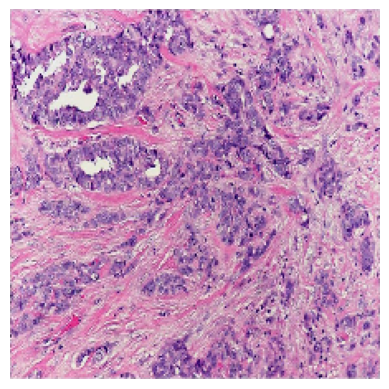

In [57]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = "/content/invasive-ductal-carcinoma.jpg"

img = image.load_img(img_path, target_size=(224,224))

plt.imshow(img)
plt.axis('off')

In [58]:
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

In [59]:
prediction = model.predict(img_array)[0][0]

print("Raw Prediction:", prediction)

if prediction > 0.5:
    print("Malignant")
else:
    print("Benign")

confidence = prediction if prediction > 0.5 else (1 - prediction)
print(f"Confidence: {confidence*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Raw Prediction: 0.5295324
Malignant
Confidence: 52.95%


In [60]:
import random

img_path = random.choice(test_generator.filepaths)
print(img_path)

/content/data/test/malignant/malignant_SOB_ductal_carcinoma_SOB_M_DC_14-17614_400X_SOB_M_DC-14-17614-400-011.png
